# 01 - Exploratory Data Analysis

## 1. Library Imports and Configuration


In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 


## 2. Continuous Dataset Loading

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("saurabhshahane/electricity-load-forecasting")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ivoto\.cache\kagglehub\datasets\saurabhshahane\electricity-load-forecasting\versions\1


In [22]:
df = pd.read_csv('../data/raw/continuous_dataset.csv', parse_dates=['datetime'], index_col='datetime')
df.sort_index()
df

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-26 20:00:00,1128.5592,27.246545,0.020303,0.055511,9.289304,25.715295,0.019746,0.121552,1.990773,23.746545,0.018381,0.150879,2.444658,0,0,1
2020-06-26 21:00:00,1112.7488,27.099573,0.020395,0.053848,9.837504,25.552698,0.019632,0.153870,2.094459,23.693323,0.018320,0.156311,2.515814,0,0,1
2020-06-26 22:00:00,1081.5680,26.971155,0.020448,0.057251,10.262464,25.393030,0.019518,0.144531,2.396369,23.658655,0.018327,0.153259,2.800717,0,0,1


## 3. Basic Dataset Inspection

In [23]:
'''
Why this matters: inspect the first rows to understand each column,
confirm that the datetime field is parsed correctly, and check for
obvious anomalies such as missing values or negative demand.

Typical conclusion: the dataset contains hourly demand, weather, and
holiday features that can be used for supervised forecasting.
'''
df.head()


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [24]:
df.info()
'''
Why this matters: review the number of rows, column types, and non-null
counts before modeling.

Typical conclusion: the dataset has about 50k hourly observations over
multiple years and `nat_demand` is usable as the forecasting target.
'''


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48048 entries, 2015-01-03 01:00:00 to 2020-06-27 00:00:00
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   nat_demand  48048 non-null  float64
 1   T2M_toc     48048 non-null  float64
 2   QV2M_toc    48048 non-null  float64
 3   TQL_toc     48048 non-null  float64
 4   W2M_toc     48048 non-null  float64
 5   T2M_san     48048 non-null  float64
 6   QV2M_san    48048 non-null  float64
 7   TQL_san     48048 non-null  float64
 8   W2M_san     48048 non-null  float64
 9   T2M_dav     48048 non-null  float64
 10  QV2M_dav    48048 non-null  float64
 11  TQL_dav     48048 non-null  float64
 12  W2M_dav     48048 non-null  float64
 13  Holiday_ID  48048 non-null  int64  
 14  holiday     48048 non-null  int64  
 15  school      48048 non-null  int64  
dtypes: float64(13), int64(3)
memory usage: 6.2 MB


'\nWhy this matters: review the number of rows, column types, and non-null\ncounts before modeling.\n\nTypical conclusion: the dataset has about 50k hourly observations over\nmultiple years and `nat_demand` is usable as the forecasting target.\n'

In [25]:
df.describe()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
count,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000,48048.000000
mean,1182.868647,27.399111,0.018313,0.079979,13.391049,26.921023,0.017844,0.106265,7.046675,24.719513,0.016867,0.144681,3.567589,0.704795,0.062937,0.727793
std,192.068896,1.675462,0.001607,0.065589,7.295502,3.018129,0.001889,0.086293,4.103711,2.414019,0.001584,0.087899,1.710522,3.147470,0.242852,0.445100
min,85.192500,22.953455,0.012054,0.000000,0.008979,19.765222,0.010247,0.000009,0.060394,19.933740,0.009655,0.000032,0.015497,0.000000,0.000000,0.000000
25%,1020.056900,26.160455,0.017236,0.026451,7.544958,24.769281,0.016584,0.036819,3.955051,22.954652,0.015800,0.075775,2.298887,0.000000,0.000000,0.000000
50%,1168.427700,27.118051,0.018590,0.065201,12.182103,26.167352,0.018351,0.085968,5.992762,24.001718,0.017167,0.130188,3.413994,0.000000,0.000000,1.000000
75%,1327.563950,28.558344,0.019521,0.117310,18.661282,28.712335,0.019242,0.157288,9.409871,26.243402,0.018067,0.200012,4.670628,0.000000,0.000000,1.000000
max,1754.882000,35.039575,0.022690,0.521240,39.229726,39.063440,0.022165,0.484985,24.483937,34.216211,0.021066,0.477783,10.288902,22.000000,1.000000,1.000000


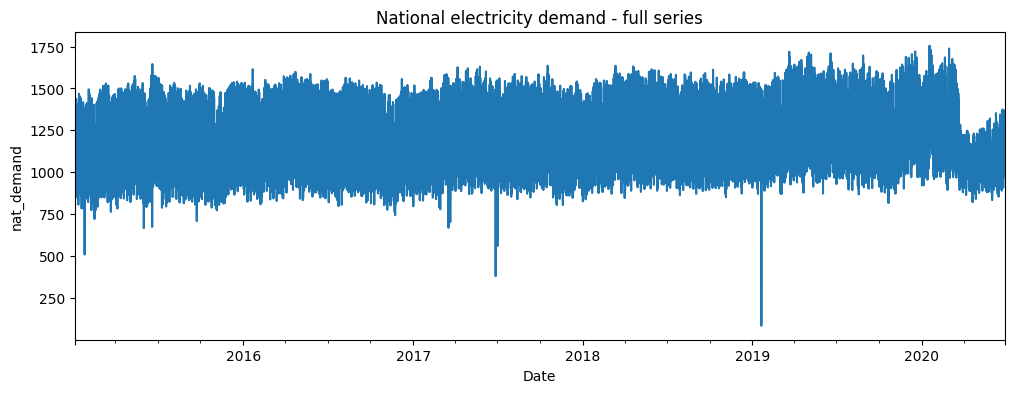

In [26]:
plt.figure(figsize=(12,4))
df['nat_demand'].plot()
plt.title('National electricity demand - full series')
plt.ylabel('nat_demand')
plt.xlabel('Date')
plt.show()


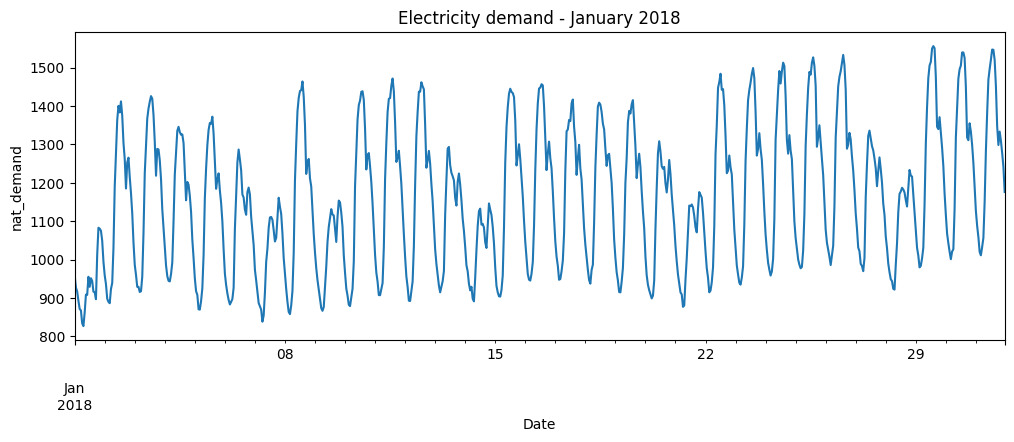

In [27]:
# Reconstruct one month
plt.figure(figsize=(12,4))
df['2018-01-01':'2018-01-31']['nat_demand'].plot()
plt.title('Electricity demand - January 2018')
plt.ylabel('nat_demand')
plt.xlabel('Date')
plt.show()


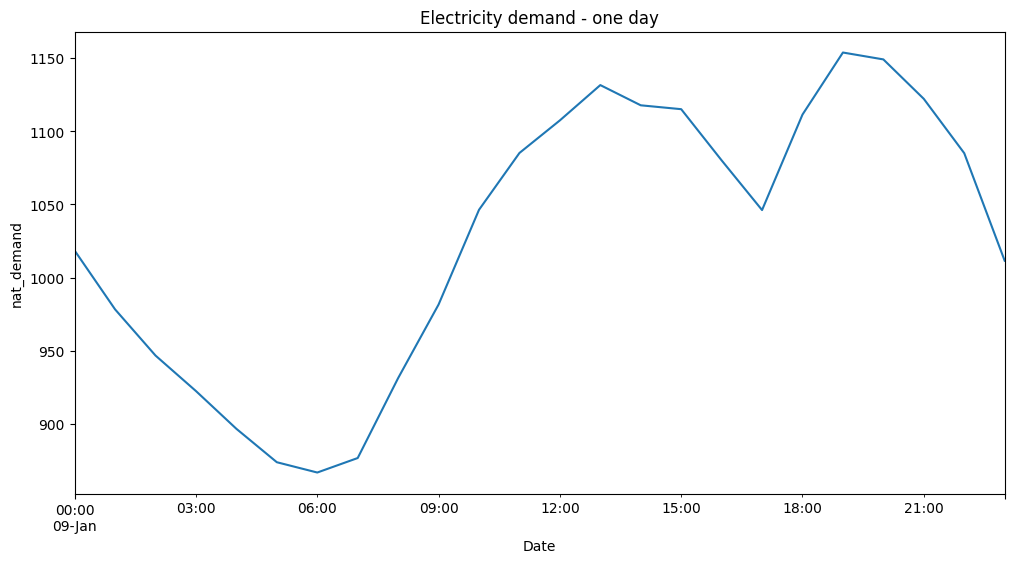

In [28]:
# Reconstruct one day
plt.figure(figsize=(12, 6))
df['2018-01-09':'2018-01-09']['nat_demand'].plot()
plt.title('Electricity demand - one day')
plt.ylabel('nat_demand')
plt.xlabel('Date')
plt.show()


In [29]:
# Reconstruct a typical day


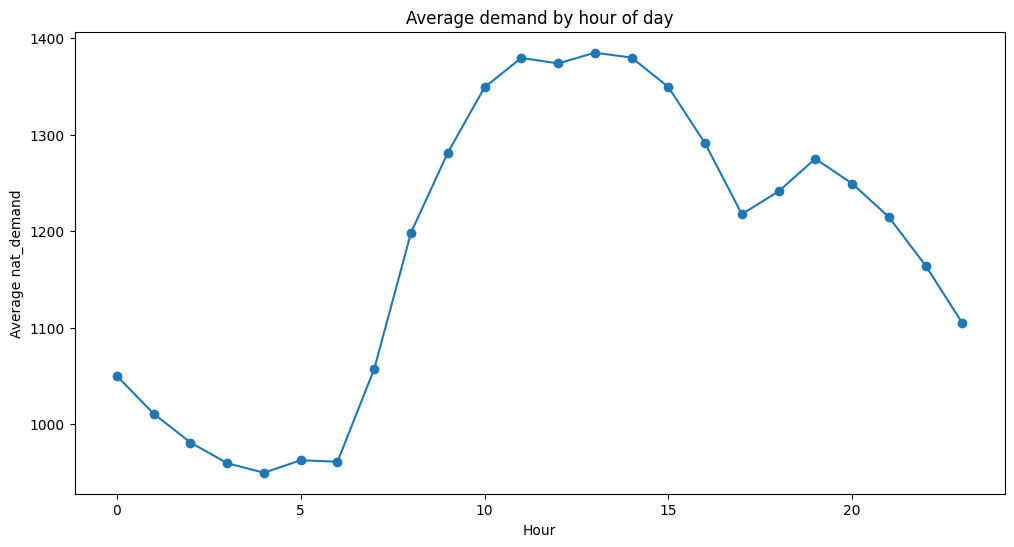

In [30]:
df['hour'] = df.index.hour
hourly_profile = df.groupby('hour')['nat_demand'].mean()

hourly_profile.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Average demand by hour of day')
plt.xlabel('Hour')
plt.ylabel('Average nat_demand')
plt.show()


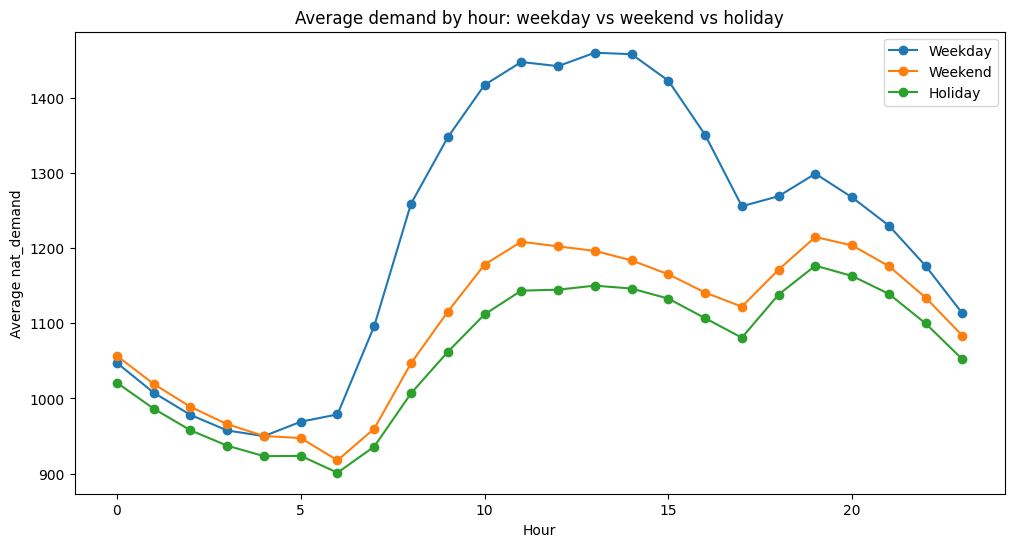

In [31]:
df['dayofweek'] = df.index.day_of_week
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

weekday_profile = df[df['is_weekend'] == 0].groupby('hour')['nat_demand'].mean()
weekend_profile = df[df['is_weekend'] == 1].groupby('hour')['nat_demand'].mean()
holiday_profile = df[df['holiday'] == 1].groupby('hour')['nat_demand'].mean()

plt.figure(figsize=(12,6))
weekday_profile.plot(marker='o', label='Weekday')
weekend_profile.plot(marker='o', label='Weekend')
holiday_profile.plot(marker='o', label='Holiday')

plt.title('Average demand by hour: weekday vs weekend vs holiday')
plt.xlabel('Hour')
plt.ylabel('Average nat_demand')
plt.legend()
plt.show()


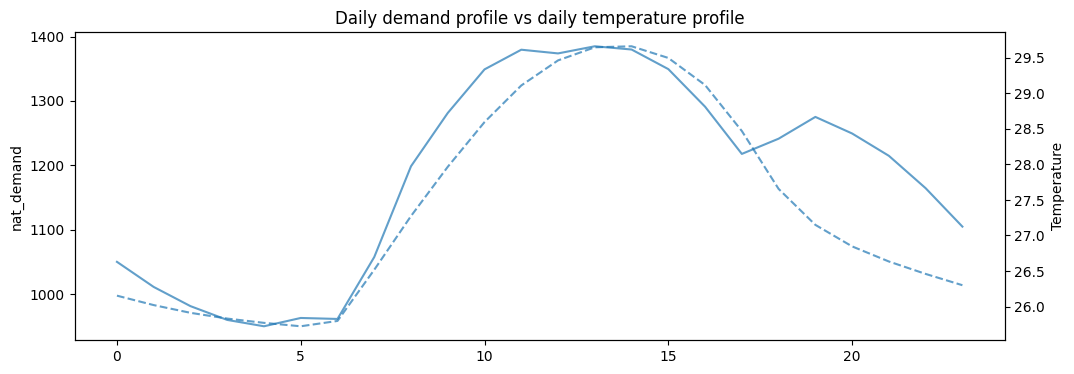

In [32]:
hourly_temperature_profile = df.groupby('hour')['T2M_toc'].mean()
hourly_demand_profile = df.groupby('hour')['nat_demand'].mean()

fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(hourly_demand_profile, label='Demand', alpha=0.7)
ax1.set_ylabel('nat_demand')

ax2 = ax1.twinx()
ax2.plot(hourly_temperature_profile, label='T2M_toc (temperature)', alpha=0.7, linestyle='--')
ax2.set_ylabel('Temperature')

plt.title('Daily demand profile vs daily temperature profile')
plt.show()


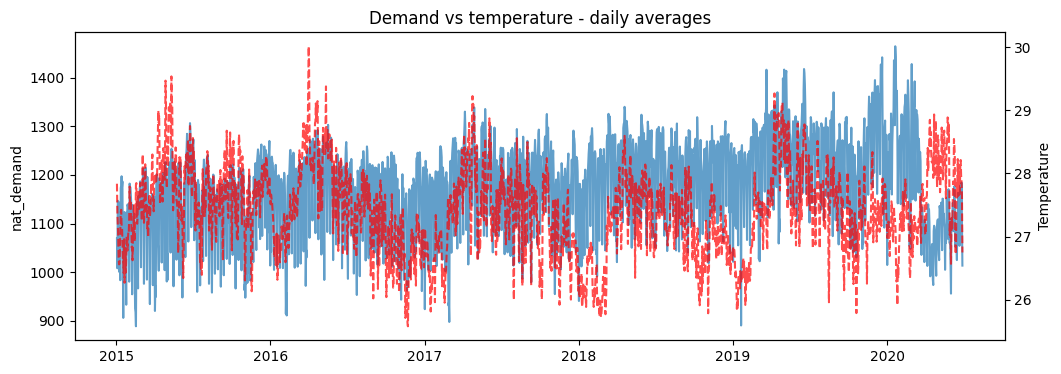

In [33]:
import matplotlib.pyplot as plt

# Daily averages for demand and temperature
daily = df.resample('D').mean()

fig, ax1 = plt.subplots(figsize=(12,4))

ax1.plot(daily.index, daily['nat_demand'], label='Demand', alpha=0.7)
ax1.set_ylabel('nat_demand')

ax2 = ax1.twinx()
ax2.plot(daily.index, daily['T2M_toc'], label='T2M_toc (temperature)', alpha=0.7, linestyle='--', color='red')
ax2.set_ylabel('Temperature')

plt.title('Demand vs temperature - daily averages')
plt.show()


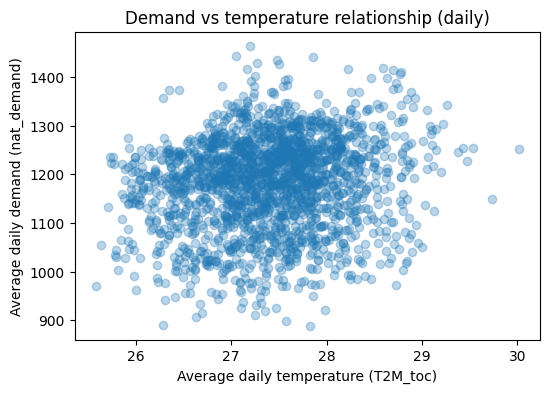

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(daily['T2M_toc'], daily['nat_demand'], alpha=0.3)
plt.xlabel('Average daily temperature (T2M_toc)')
plt.ylabel('Average daily demand (nat_demand)')
plt.title('Demand vs temperature relationship (daily)')
plt.show()


In [35]:
df[['T2M_toc', 'T2M_san', 'T2M_dav']].describe()

,T2M_toc,T2M_san,T2M_dav
count,48048.000000,48048.000000,48048.000000
mean,27.399111,26.921023,24.719513
std,1.675462,3.018129,2.414019
min,22.953455,19.765222,19.933740
25%,26.160455,24.769281,22.954652
50%,27.118051,26.167352,24.001718
75%,28.558344,28.712335,26.243402
max,35.039575,39.063440,34.216211


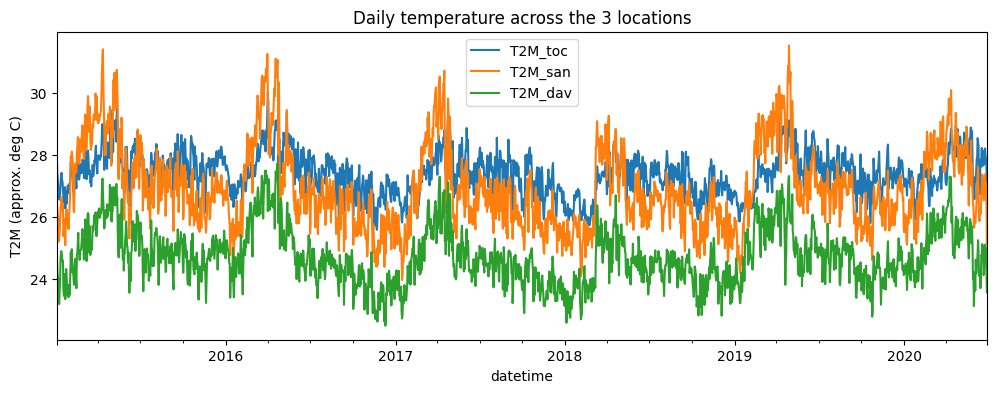

In [36]:
daily_temp = df[['T2M_toc', 'T2M_san', 'T2M_dav']].resample('D').mean()

daily_temp.plot(figsize=(12,4))
plt.title('Daily temperature across the 3 locations')
plt.ylabel('T2M (approx. deg C)')
plt.show()


In [37]:
num_cols = [
    'nat_demand',
    'T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
    'T2M_san','QV2M_san','TQL_san','W2M_san',
    'T2M_dav','QV2M_dav','TQL_dav','W2M_dav'
]

corr_with_nat = df[num_cols].corr()['nat_demand'].sort_values(ascending=False)
corr_with_nat


nat_demand    1.000000
T2M_toc       0.652811
T2M_dav       0.648279
T2M_san       0.627024
W2M_san       0.191796
TQL_san       0.119038
W2M_toc       0.098435
TQL_toc       0.073109
TQL_dav       0.042037
QV2M_san      0.022172
QV2M_dav     -0.002117
QV2M_toc     -0.036706
W2M_dav      -0.054802
Name: nat_demand, dtype: float64

In [38]:
df['Holiday_ID'].value_counts()


Holiday_ID
0     45024
12      168
2       144
4       144
5       144
6       144
3       144
7       144
8       144
10      144
9       144
11      144
1       144
19      144
16      144
21      144
15      120
13      120
14      120
18      120
17      120
20      120
22      120
Name: count, dtype: int64

## Exploratory Data Analysis Summary

### 1. Dataset Structure

- **Source:** Electricity Load Forecasting (Kaggle).
- **Frequency:** hourly data.
- **Date range:** from `2015-01-03 01:00` to `2020-06-27 00:00` (about 5.5 years).
- **Size:** 48,048 rows and 16 numeric columns (`datetime` index).
- **Quality:** no missing values or duplicated timestamps were found.

Main columns:
- `nat_demand`: national electricity demand (target).
- Weather variables across 3 locations (`toc`, `san`, `dav`):
  `T2M_*` (temperature), `QV2M_*` (specific humidity),
  `TQL_*` (liquid water/cloud cover), `W2M_*` (wind speed).
- Calendar variables: `Holiday_ID`, `holiday` (0/1), `school` (0/1).

---

### 2. Demand Behavior (`nat_demand`)

Basic statistics:

- Mean around **1183**
- Standard deviation around **192**
- Minimum around **85**
- Maximum around **1755**

Interpretation:
- Hourly demand usually moves between roughly **1000 and 1400**.
- There are some unusually low outliers, but the overall range is plausible.

The full time series shows:
- A relatively stable series around the mean, without a strong long-term trend.
- Persistent oscillations plus a few isolated low points.

The monthly zoom, for example January 2018, clearly shows:
- **Daily seasonality:** demand falls overnight, rises during the day, and falls again at night.
- Differences between days that suggest a **weekly effect**.

The average hourly profile shows:
- Minimum demand around 0-5 h.
- A fast increase from 6-7 h.
- A main peak around 10-14 h.
- A second shoulder in the late afternoon and evening.

Conclusion: the model must capture a strong daily pattern.

---

### 3. Calendar Effects

Created variables:
- `hour`: hour of day (0-23).
- `dayofweek`: day of week (0=Monday, ..., 6=Sunday).
- `is_weekend`: 1 for Saturday or Sunday, otherwise 0.

Average hourly profiles were compared for:
- weekdays;
- weekends;
- holidays (`holiday=1`).

Results:
- The daily shape is similar across the three groups.
- The level changes: weekdays > weekends > holidays.
- The difference is especially large during central daytime hours, roughly 8-17 h.
- `Holiday_ID` has many infrequent categories, so the binary `holiday` flag is used first.
- `school` adds complementary calendar information.

Conclusion: calendar variables (`hour`, `dayofweek`, `is_weekend`, `holiday`, `school`) are highly relevant features.

---

### 4. Weather Effects

Temperature comparison:
- `T2M_toc`, `T2M_san`, and `T2M_dav` show very similar annual patterns.
- Approximate range: 20-39 deg C, with level differences across locations.

Correlation with `nat_demand`:

- `T2M_toc` around **0.65**
- `T2M_dav` around **0.65**
- `T2M_san` around **0.63**
- Wind (`W2M_*`): weak correlations, around 0.1-0.2.
- Cloud/liquid water (`TQL_*`) and humidity (`QV2M_*`): very low or near-zero correlations.

Daily demand vs temperature profile:
- Demand and temperature rise and fall at roughly similar times during the day.

Daily scatter plot:
- The relationship is positive but dispersed: temperature helps, but does not explain all demand variability.

Conclusion: **temperature is the most important weather variable**; wind, cloud cover, and humidity appear less informative for a first model.

---

### 5. Modeling Decisions from the EDA

For the first LSTM demand forecasting model:

1. **Target**
   - `nat_demand`.

2. **Main input features**
   - Historical `nat_demand` inside the lookback window.
   - Temperature at the 3 locations: `T2M_toc`, `T2M_san`, `T2M_dav`.
   - Calendar variables: `hour`, `dayofweek`, `is_weekend`, `holiday`, `school`.

3. **Rationale**
   - Daily and weekly demand patterns are strong, so calendar features are required.
   - Temperature is highly correlated with demand and has similar daily profiles, making it the key weather covariate.
   - Other weather variables show weaker correlations, so they can be excluded from the initial model to reduce noise.

This EDA supports the data preparation and LSTM windowing workflow and documents why these features were selected first.
